Quest P1-1. 작은 FASTA 예시 직접 만들기

In [2]:
import pandas as pd
import numpy as np

In [3]:
fasta_text = """>P001 Example protein 1
MALWMRLLPLLALLALWGPDPAAA
>P002 Example protein 2
MKTFFVAGVILALALATEQA
>P003 Example protein 3
GAVLIPFWYCMSTNQDEKRH
"""

print(fasta_text)

>P001 Example protein 1
MALWMRLLPLLALLALWGPDPAAA
>P002 Example protein 2
MKTFFVAGVILALALATEQA
>P003 Example protein 3
GAVLIPFWYCMSTNQDEKRH



Quest P1-2. FASTA 파싱하기

In [4]:
{
    "P001": "MALWMRLLPLLALLALWGPDPAAA",
    "P002": "MKTFFVAGVILALALATEQA",
    "P003": "GAVLIPFWYCMSTNQDEKRH"
}

protein_sequences = {}

current_id = None
current_sequence = []

for line in fasta_text.splitlines():
    line = line.strip()

    if line.startswith(">"):
        if current_id is not None:
            protein_sequences[current_id] = "".join(current_sequence)

        header = line[1:]
        current_id = header.split()[0]
        current_sequence = []
    else:
        current_sequence.append(line)

if current_id is not None:
    protein_sequences[current_id] = "".join(current_sequence)

print(protein_sequences)

{'P001': 'MALWMRLLPLLALLALWGPDPAAA', 'P002': 'MKTFFVAGVILALALATEQA', 'P003': 'GAVLIPFWYCMSTNQDEKRH'}


Quest P2-1. 허용할 아미노산 문자 정의하기

In [5]:
valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

print(valid_amino_acids)
print(len(valid_amino_acids))

{'P', 'C', 'W', 'E', 'K', 'S', 'A', 'G', 'Y', 'L', 'F', 'M', 'D', 'V', 'T', 'I', 'R', 'Q', 'N', 'H'}
20


Quest P2-2. sequence 하나 검증하기 (비정상 찾기)

In [6]:
def check_invalid_amino_acids(sequence):
    sequence_letters = set(sequence)
    invalid_letters = sequence_letters - valid_amino_acids
    return invalid_letters

print(check_invalid_amino_acids("MALWMRLLPLLALLALWGPDPAAA"))
print(check_invalid_amino_acids("MALWMRLLPLLALLALXGPDPAAA"))

set()
{'X'}


Quest P2-3. 전체 예시 sequence 검증하기

In [7]:
for protein_id, sequence in protein_sequences.items():
    invalid = check_invalid_amino_acids(sequence)
    print(protein_id, invalid)

P001 set()
P002 set()
P003 set()


Quest P3. Amino Acid Composition Feature 만들기

A = 2/4 = 0.5,
G = 1/4 = 0.25,
T = 1/4 = 0.25

Quest P3-1. 아미노산 개수 세기

In [8]:
example_sequence = "AAGT"

aa_counts = {}

for aa in valid_amino_acids:
    aa_counts[aa] = example_sequence.count(aa)

print(aa_counts)

{'P': 0, 'C': 0, 'W': 0, 'E': 0, 'K': 0, 'S': 0, 'A': 2, 'G': 1, 'Y': 0, 'L': 0, 'F': 0, 'M': 0, 'D': 0, 'V': 0, 'T': 1, 'I': 0, 'R': 0, 'Q': 0, 'N': 0, 'H': 0}


Quest P3-2. 개수를 비율로 바꾸기

In [9]:
aa_composition = {}

sequence_length = len(example_sequence)

for aa in valid_amino_acids:
    aa_composition[aa] = example_sequence.count(aa) / sequence_length

print(aa_composition)

{'P': 0.0, 'C': 0.0, 'W': 0.0, 'E': 0.0, 'K': 0.0, 'S': 0.0, 'A': 0.5, 'G': 0.25, 'Y': 0.0, 'L': 0.0, 'F': 0.0, 'M': 0.0, 'D': 0.0, 'V': 0.0, 'T': 0.25, 'I': 0.0, 'R': 0.0, 'Q': 0.0, 'N': 0.0, 'H': 0.0}


Quest P3-3. 함수로 만들기

In [10]:
def calculate_aa_composition(sequence):
    composition = {}
    sequence_length = len(sequence)

    for aa in sorted(valid_amino_acids):
        composition[f"aa_{aa}"] = sequence.count(aa) / sequence_length

    return composition

print(calculate_aa_composition("AAGT"))

{'aa_A': 0.5, 'aa_C': 0.0, 'aa_D': 0.0, 'aa_E': 0.0, 'aa_F': 0.0, 'aa_G': 0.25, 'aa_H': 0.0, 'aa_I': 0.0, 'aa_K': 0.0, 'aa_L': 0.0, 'aa_M': 0.0, 'aa_N': 0.0, 'aa_P': 0.0, 'aa_Q': 0.0, 'aa_R': 0.0, 'aa_S': 0.0, 'aa_T': 0.25, 'aa_V': 0.0, 'aa_W': 0.0, 'aa_Y': 0.0}


Quest P3-4. 전체 단백질 예시에 적용하기

In [11]:
composition_rows = []

for protein_id, sequence in protein_sequences.items():
    row = calculate_aa_composition(sequence)
    row["protein_id"] = protein_id
    row["sequence"] = sequence
    composition_rows.append(row)

composition_df = pd.DataFrame(composition_rows)

print(composition_df.head())
print(composition_df.shape)

   aa_A  aa_C      aa_D  aa_E  aa_F      aa_G  aa_H  aa_I  aa_K      aa_L  \
0  0.25  0.00  0.041667  0.00  0.00  0.041667  0.00  0.00  0.00  0.333333   
1  0.25  0.00  0.000000  0.05  0.10  0.050000  0.00  0.05  0.05  0.150000   
2  0.05  0.05  0.050000  0.05  0.05  0.050000  0.05  0.05  0.05  0.050000   

   ...   aa_P  aa_Q      aa_R  aa_S  aa_T  aa_V      aa_W  aa_Y  protein_id  \
0  ...  0.125  0.00  0.041667  0.00  0.00  0.00  0.083333  0.00        P001   
1  ...  0.000  0.05  0.000000  0.00  0.10  0.10  0.000000  0.00        P002   
2  ...  0.050  0.05  0.050000  0.05  0.05  0.05  0.050000  0.05        P003   

                   sequence  
0  MALWMRLLPLLALLALWGPDPAAA  
1      MKTFFVAGVILALALATEQA  
2      GAVLIPFWYCMSTNQDEKRH  

[3 rows x 22 columns]
(3, 22)


Quest P4-1. 단백질 2-mer 만들기

In [12]:
example_protein = "MALW"
k = 2

protein_kmers = []

for i in range(len(example_protein) - k + 1):
    kmer = example_protein[i:i+k]
    protein_kmers.append(kmer)

print(protein_kmers)

['MA', 'AL', 'LW']


Quest P4-2. 함수로 만들기

In [13]:
def make_protein_kmers(sequence, k):
    kmers = []

    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        kmers.append(kmer)

    return kmers

print(make_protein_kmers("MALW", 2))
print(make_protein_kmers("MALWMR", 3))

['MA', 'AL', 'LW']
['MAL', 'ALW', 'LWM', 'WMR']


Quest P4-3. 2-mer count 보기

In [14]:
from collections import Counter

example_kmers = make_protein_kmers("MALWMALW", 2)

kmer_counts = Counter(example_kmers)

print(example_kmers)
print(kmer_counts)
print(kmer_counts.most_common())

['MA', 'AL', 'LW', 'WM', 'MA', 'AL', 'LW']
Counter({'MA': 2, 'AL': 2, 'LW': 2, 'WM': 1})
[('MA', 2), ('AL', 2), ('LW', 2), ('WM', 1)]


Quest P4-4. 전체 예시 데이터에서 2-mer vocabulary 만들기

In [15]:
all_protein_2mers = []

for sequence in protein_sequences.values():
    kmers = make_protein_kmers(sequence, 2)
    all_protein_2mers.extend(kmers)

protein_2mer_vocabulary = sorted(set(all_protein_2mers))

print(protein_2mer_vocabulary)
print(len(protein_2mer_vocabulary))

['AA', 'AG', 'AL', 'AT', 'AV', 'CM', 'DE', 'DP', 'EK', 'EQ', 'FF', 'FV', 'FW', 'GA', 'GP', 'GV', 'IL', 'IP', 'KR', 'KT', 'LA', 'LI', 'LL', 'LP', 'LW', 'MA', 'MK', 'MR', 'MS', 'NQ', 'PA', 'PD', 'PF', 'PL', 'QA', 'QD', 'RH', 'RL', 'ST', 'TE', 'TF', 'TN', 'VA', 'VI', 'VL', 'WG', 'WM', 'WY', 'YC']
49


Quest P4-5. sequence 하나를 2-mer count vector로 바꾸기

In [16]:
first_protein_id = list(protein_sequences.keys())[0]
first_protein_sequence = protein_sequences[first_protein_id]

first_2mer_counts = Counter(make_protein_kmers(first_protein_sequence, 2))

first_2mer_vector = []

for kmer in protein_2mer_vocabulary:
    count = first_2mer_counts[kmer]
    first_2mer_vector.append(count)

print(first_protein_id)
print(first_2mer_vector)
print(len(first_2mer_vector))
print(sum(first_2mer_vector))

P001
[2, 0, 3, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 3, 1, 2, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0]
49
23


Quest P5-1. UniProt 검색 URL 이해하기

reviewed:true,
organism_id:9606,
subcellular location:nucleus

In [17]:
import requests
import pandas as pd
from io import StringIO
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://rest.uniprot.org/uniprotkb/search"

params = {
    "query": "(reviewed:true) AND (organism_id:9606) AND (cc_subcellular_location:nucleus)",
    "format": "tsv",
    "fields": "accession,protein_name,gene_names,organism_name,cc_subcellular_location,sequence",
    "size": 10
}

response = requests.get(url, params=params, verify=False)

print(response.status_code)
print(response.text[:500])

200
Entry	Protein names	Gene Names	Organism	Subcellular location [CC]	Sequence
P42285	Exosome RNA helicase MTR4 (EC 3.6.4.13) (ATP-dependent RNA helicase DOB1) (ATP-dependent RNA helicase SKIV2L2) (Superkiller viralicidic activity 2-like 2) (TRAMP-like complex helicase)	MTREX DOB1 KIAA0052 MTR4 SKIV2L2	Homo sapiens (Human)	SUBCELLULAR LOCATION: Nucleus, nucleoplasm {ECO:0000269|PubMed:30842217}. Nucleus, nucleolus {ECO:0000269|PubMed:12429849}. Nucleus {ECO:0000269|PubMed:16782053}. Nucleus speckle 


단백질 ID

단백질 이름

유전자명

세포 내 위치 annotation

아미노산 sequence

Quest P5-3. TSV 응답을 DataFrame으로 바꾸기

In [18]:
uniprot_sample_df = pd.read_csv(
    StringIO(response.text),
    sep="\t"
)

print(uniprot_sample_df.head())
print(uniprot_sample_df.shape)
print(uniprot_sample_df.columns)

    Entry                                      Protein names  \
0  P42285  Exosome RNA helicase MTR4 (EC 3.6.4.13) (ATP-d...   
1  Q9H7Z3  Nuclear exosome regulator NRDE2 (Protein NRDE2...   
2  Q68DK7  Male-specific lethal 1 homolog (MSL-1) (Male-s...   
3  Q02880  DNA topoisomerase 2-beta (EC 5.6.2.2) (DNA top...   
4  Q9Y2W1  Thyroid hormone receptor-associated protein 3 ...   

                         Gene Names              Organism  \
0  MTREX DOB1 KIAA0052 MTR4 SKIV2L2  Homo sapiens (Human)   
1                   NRDE2 C14orf102  Homo sapiens (Human)   
2                       MSL1 MSL1L1  Homo sapiens (Human)   
3                             TOP2B  Homo sapiens (Human)   
4             THRAP3 BCLAF2 TRAP150  Homo sapiens (Human)   

                           Subcellular location [CC]  \
0  SUBCELLULAR LOCATION: Nucleus, nucleoplasm {EC...   
1  SUBCELLULAR LOCATION: Nucleus speckle {ECO:000...   
2  SUBCELLULAR LOCATION: Nucleus {ECO:0000269|Pub...   
3  SUBCELLULAR LOCATION:

Quest P5-4. 로컬 TSV 파일 읽기

In [3]:
from pathlib import Path

print(Path.cwd())

c:\Users\hakyh\OneDrive\Desktop\AI_헬스케어_부트캠프\딥러닝\개인 프로젝트\protein_loc_ai


In [4]:
raw_dir = Path("data/raw")

print(raw_dir.exists())

for file in raw_dir.iterdir():
    print(file)

True
data\raw\uniprot_cytoplasm.tsv
data\raw\uniprot_mitochondrion.tsv
data\raw\uniprot_nucleus.tsv


In [5]:
from pathlib import Path

import pandas as pd

raw_dir = Path("data/raw")

nucleus_path = raw_dir / "uniprot_nucleus.tsv"
cytoplasm_path = raw_dir / "uniprot_cytoplasm.tsv"
mitochondrion_path = raw_dir / "uniprot_mitochondrion.tsv"

nucleus_df = pd.read_csv(nucleus_path, sep="\t")
cytoplasm_df = pd.read_csv(cytoplasm_path, sep="\t")
mitochondrion_df = pd.read_csv(mitochondrion_path, sep="\t")

print("nucleus:", nucleus_df.shape)
print("cytoplasm:", cytoplasm_df.shape)
print("mitochondrion:", mitochondrion_df.shape)

print(nucleus_df.head())

nucleus: (5794, 9)
cytoplasm: (5883, 9)
mitochondrion: (1369, 9)
        Entry  Reviewed   Entry Name  \
0  A0A0C5B5G6  reviewed  MOTSC_HUMAN   
1  A0A2R8Y7D0  reviewed  TINCR_HUMAN   
2  A0A8I5KQE6  reviewed  RPSA2_HUMAN   
3      A0AV96  reviewed  RBM47_HUMAN   
4      A0AVK6  reviewed   E2F8_HUMAN   

                                       Protein names  \
0  Mitochondrial-derived peptide MOTS-c (Mitochon...   
1  Ubiquitin domain-containing protein TINCR (Pla...   
2  Small ribosomal subunit protein uS2B (37 kDa l...   
3  RNA-binding protein 47 (RNA-binding motif prot...   
4                  Transcription factor E2F8 (E2F-8)   

                         Gene Names              Organism  Length  \
0                           MT-RNR1  Homo sapiens (Human)      16   
1  TINCR LINC00036 NCRNA00036 PLAC2  Homo sapiens (Human)      87   
2                RPSA2 RPSA RPSAP58  Homo sapiens (Human)     295   
3                             RBM47  Homo sapiens (Human)     593   
4           

Quest P5-5. label 컬럼 추가

In [6]:
nucleus_df["label"] = "nucleus"
cytoplasm_df["label"] = "cytoplasm"
mitochondrion_df["label"] = "mitochondrion"

In [7]:
protein_df = pd.concat(
    [nucleus_df, cytoplasm_df, mitochondrion_df],
    axis=0
).reset_index(drop=True)

print(protein_df.shape)
print(protein_df["label"].value_counts())
print(protein_df.head())

(13046, 10)
label
cytoplasm        5883
nucleus          5794
mitochondrion    1369
Name: count, dtype: int64
        Entry  Reviewed   Entry Name  \
0  A0A0C5B5G6  reviewed  MOTSC_HUMAN   
1  A0A2R8Y7D0  reviewed  TINCR_HUMAN   
2  A0A8I5KQE6  reviewed  RPSA2_HUMAN   
3      A0AV96  reviewed  RBM47_HUMAN   
4      A0AVK6  reviewed   E2F8_HUMAN   

                                       Protein names  \
0  Mitochondrial-derived peptide MOTS-c (Mitochon...   
1  Ubiquitin domain-containing protein TINCR (Pla...   
2  Small ribosomal subunit protein uS2B (37 kDa l...   
3  RNA-binding protein 47 (RNA-binding motif prot...   
4                  Transcription factor E2F8 (E2F-8)   

                         Gene Names              Organism  Length  \
0                           MT-RNR1  Homo sapiens (Human)      16   
1  TINCR LINC00036 NCRNA00036 PLAC2  Homo sapiens (Human)      87   
2                RPSA2 RPSA RPSAP58  Homo sapiens (Human)     295   
3                             RBM47 

Quest P5-6. 중복 단백질 확인하기

In [8]:
print(protein_df.columns)

Index(['Entry', 'Reviewed', 'Entry Name', 'Protein names', 'Gene Names',
       'Organism', 'Length', 'Subcellular location [CC]', 'Sequence', 'label'],
      dtype='object')


In [9]:
entry_counts = protein_df["Entry"].value_counts()

print(entry_counts.head(20))
print("중복 Entry 개수:", (entry_counts > 1).sum())
print("전체 고유 Entry 개수:", protein_df["Entry"].nunique())

Entry
P00374    3
P35232    3
Q9Y2N7    3
P49419    3
P02760    3
O15164    3
Q15046    3
Q96Q11    3
P56693    3
P04049    3
P35557    3
P15336    3
P04150    3
Q15311    3
O15294    3
Q9H7D7    3
P04637    3
Q8N6R0    3
Q9H773    3
Q96PN6    3
Name: count, dtype: int64
중복 Entry 개수: 2795
전체 고유 Entry 개수: 10066


Quest P5-7. 중복 Entry 제거하기

In [10]:
entry_counts = protein_df["Entry"].value_counts()

unique_entries = entry_counts[entry_counts == 1].index

protein_single_label_df = protein_df[
    protein_df["Entry"].isin(unique_entries)
].copy()

print(protein_single_label_df.shape)
print(protein_single_label_df["label"].value_counts())
print("고유 Entry 개수:", protein_single_label_df["Entry"].nunique())

(7271, 10)
label
nucleus          3173
cytoplasm        3148
mitochondrion     950
Name: count, dtype: int64
고유 Entry 개수: 7271


### 현재 데이터 상태 해석

- 단일 label 분류 문제로 정리됨
- Entry 중복 없음
- nucleus/cytoplasm은 비슷한 개수


Quest P5-8. Sequence 컬럼 확인하기

In [11]:
print(protein_single_label_df.columns)
print(protein_single_label_df[["Entry", "label", "Sequence"]].head())
print(protein_single_label_df["Sequence"].isnull().sum())

Index(['Entry', 'Reviewed', 'Entry Name', 'Protein names', 'Gene Names',
       'Organism', 'Length', 'Subcellular location [CC]', 'Sequence', 'label'],
      dtype='object')
    Entry    label                                           Sequence
4  A0AVK6  nucleus  MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...
5  A0JLT2  nucleus  MENFTALFGAQADPPPPPTALGFGPGKPPPPPPPPAGGGPGTAPPP...
6  A0PJY2  nucleus  MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...
7  A0PK00  nucleus  MSGQLERCEREWHELEGEFQELQETHRIYKQKLEELAALQTLCSSS...
9  A1A519  nucleus  MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...
0


Quest P5-9. 실제 UniProt sequence 검증하기

1. invalid amino acid 확인

In [12]:
valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

def find_invalid_amino_acids(sequence):
    sequence_letters = set(sequence)
    invalid_letters = sequence_letters - valid_amino_acids
    return invalid_letters

protein_single_label_df["invalid_aa"] = protein_single_label_df["Sequence"].apply(find_invalid_amino_acids)

print(protein_single_label_df["invalid_aa"].value_counts().head(20))

invalid_aa
{}     7264
{U}       7
Name: count, dtype: int64


2. invalid sequence 개수 확인

In [13]:
invalid_mask = protein_single_label_df["invalid_aa"].apply(lambda x: len(x) > 0)

print("invalid sequence 개수:", invalid_mask.sum())
print("valid sequence 개수:", (~invalid_mask).sum())

invalid sequence 개수: 7
valid sequence 개수: 7264


Quest P5-10. invalid sequence 제거하기

In [14]:
protein_clean_df = protein_single_label_df[
    ~invalid_mask
].copy()

print(protein_clean_df.shape)
print(protein_clean_df["label"].value_counts())
print(protein_clean_df["invalid_aa"].value_counts())

(7264, 11)
label
nucleus          3173
cytoplasm        3143
mitochondrion     948
Name: count, dtype: int64
invalid_aa
{}    7264
Name: count, dtype: int64


sequence 길이 컬럼 추가

In [15]:
protein_clean_df["sequence_length"] = protein_clean_df["Sequence"].str.len()

print(protein_clean_df["sequence_length"].describe())
print(protein_clean_df.groupby("label")["sequence_length"].describe())

count    7264.000000
mean      615.346641
std       574.532288
min        24.000000
25%       289.000000
50%       466.000000
75%       729.000000
max      8525.000000
Name: sequence_length, dtype: float64
                count        mean         std   min    25%    50%    75%  \
label                                                                      
cytoplasm      3143.0  696.232899  665.458042  24.0  307.0  509.0  850.0   
mitochondrion   948.0  375.691983  346.482728  26.0  178.0  318.0  477.5   
nucleus        3173.0  606.826978  507.543869  44.0  310.0  484.0  715.0   

                  max  
label                  
cytoplasm      8525.0  
mitochondrion  5005.0  
nucleus        5890.0  


Quest P6. EDA 시작하기

Quest P6-1. class 분포 시각화

label
nucleus          3173
cytoplasm        3143
mitochondrion     948
Name: count, dtype: int64


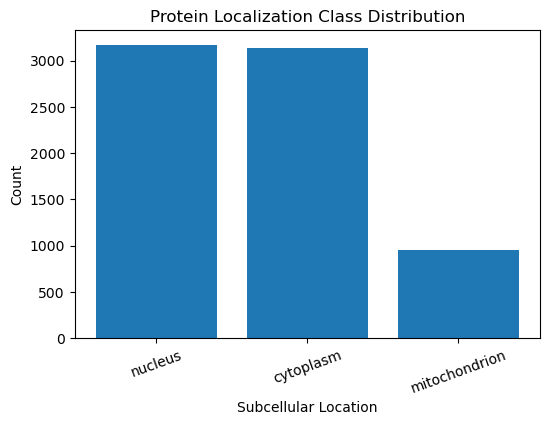

In [16]:
import matplotlib.pyplot as plt

class_counts = protein_clean_df["label"].value_counts()

print(class_counts)

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Protein Localization Class Distribution")
plt.xlabel("Subcellular Location")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

Quest P6-2. sequence length boxplot

C:\Users\hakyh\AppData\Local\Temp\ipykernel_19896\175827858.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(length_data, labels=labels, showfliers=False)


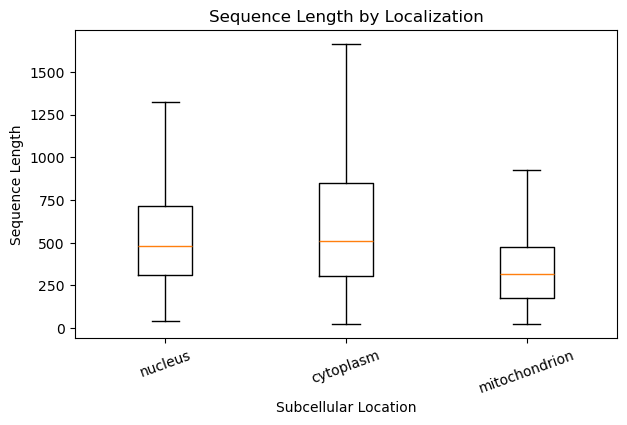

In [17]:
labels = ["nucleus", "cytoplasm", "mitochondrion"]

length_data = [
    protein_clean_df[protein_clean_df["label"] == label]["sequence_length"]
    for label in labels
]

plt.figure(figsize=(7, 4))
plt.boxplot(length_data, labels=labels, showfliers=False)
plt.title("Sequence Length by Localization")
plt.xlabel("Subcellular Location")
plt.ylabel("Sequence Length")
plt.xticks(rotation=20)
plt.show()

Quest P6-3. Amino Acid Composition 만들기

In [18]:
valid_amino_acids = sorted(list("ACDEFGHIKLMNPQRSTVWY"))

def calculate_aa_composition(sequence):
    sequence_length = len(sequence)
    composition = {}

    for aa in valid_amino_acids:
        composition[f"aa_{aa}"] = sequence.count(aa) / sequence_length

    return composition

In [19]:
first_sequence = protein_clean_df.iloc[0]["Sequence"]

first_composition = calculate_aa_composition(first_sequence)

print(first_sequence[:50])
print(first_composition)
print(sum(first_composition.values()))

MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPTKPKE
{'aa_A': 0.06805074971164937, 'aa_C': 0.012687427912341407, 'aa_D': 0.03229527104959631, 'aa_E': 0.06805074971164937, 'aa_F': 0.029988465974625143, 'aa_G': 0.05536332179930796, 'aa_H': 0.02306805074971165, 'aa_I': 0.04844290657439446, 'aa_K': 0.07381776239907728, 'aa_L': 0.08419838523644751, 'aa_M': 0.01845444059976932, 'aa_N': 0.04844290657439446, 'aa_P': 0.09111880046136102, 'aa_Q': 0.0392156862745098, 'aa_R': 0.04498269896193772, 'aa_S': 0.11995386389850057, 'aa_T': 0.058823529411764705, 'aa_V': 0.06459054209919261, 'aa_W': 0.0034602076124567475, 'aa_Y': 0.014994232987312572}
1.0


Quest P6-4. 전체 데이터에 Amino Acid Composition 적용하기

In [20]:
aa_composition_rows = []

for sequence in protein_clean_df["Sequence"]:
    composition = calculate_aa_composition(sequence)
    aa_composition_rows.append(composition)

X_aa = pd.DataFrame(aa_composition_rows)

print(X_aa.head())
print(X_aa.shape)

       aa_A      aa_C      aa_D      aa_E      aa_F      aa_G      aa_H  \
0  0.068051  0.012687  0.032295  0.068051  0.029988  0.055363  0.023068   
1  0.057377  0.012295  0.045082  0.045082  0.032787  0.090164  0.036885   
2  0.086316  0.042105  0.023158  0.031579  0.048421  0.063158  0.061053   
3  0.047198  0.026549  0.017699  0.073746  0.073746  0.047198  0.032448   
4  0.030303  0.030303  0.030303  0.148485  0.018182  0.066667  0.027273   

       aa_I      aa_K      aa_L      aa_M      aa_N      aa_P      aa_Q  \
0  0.048443  0.073818  0.084198  0.018454  0.048443  0.091119  0.039216   
1  0.024590  0.122951  0.077869  0.024590  0.036885  0.159836  0.028689   
2  0.021053  0.082105  0.086316  0.023158  0.044211  0.109474  0.042105   
3  0.035398  0.064897  0.153392  0.014749  0.041298  0.014749  0.064897   
4  0.015152  0.054545  0.054545  0.033333  0.027273  0.054545  0.063636   

       aa_R      aa_S      aa_T      aa_V      aa_W      aa_Y  
0  0.044983  0.119954  0.058824  0

label y 만들기

In [21]:
y = protein_clean_df["label"]

print(y.head())
print(y.value_counts())
print(y.shape)

4    nucleus
5    nucleus
6    nucleus
7    nucleus
9    nucleus
Name: label, dtype: object
label
nucleus          3173
cytoplasm        3143
mitochondrion     948
Name: count, dtype: int64
(7264,)


Quest P7. 첫 번째 ML Baseline 만들기
- amino acid composition만 사용해서 단백질 localization을 예측한다.

Quest P7-1. Train/Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_aa,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(5811, 20)
(1453, 20)
label
nucleus          2538
cytoplasm        2514
mitochondrion     759
Name: count, dtype: int64
label
nucleus          635
cytoplasm        629
mitochondrion    189
Name: count, dtype: int64


Quest P7-2. Logistic Regression Baseline 학습

In [23]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Quest P7-3. 예측 및 성능 평가

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.6035788024776325

               precision    recall  f1-score   support

    cytoplasm       0.64      0.50      0.57       629
mitochondrion       0.37      0.75      0.50       189
      nucleus       0.72      0.66      0.69       635

     accuracy                           0.60      1453
    macro avg       0.58      0.64      0.58      1453
 weighted avg       0.64      0.60      0.61      1453



추가: Confusion Matrix

In [25]:
cm = confusion_matrix(y_test, y_pred, labels=["nucleus", "cytoplasm", "mitochondrion"])

print(cm)

[[418 141  76]
 [147 317 165]
 [ 12  35 142]]


Quest P8. Feature 확장: sequence length 추가

Quest P8-1. X_length 만들기

In [26]:
X_length = protein_clean_df[["sequence_length"]]

print(X_length.head())
print(X_length.shape)

   sequence_length
4              867
5              244
6              475
7              339
9              330
(7264, 1)


Quest P8-2. amino acid composition + length 결합

In [27]:
X_aa_length = pd.concat(
    [X_aa, X_length],
    axis=1
)

print(X_aa.shape)
print(X_length.shape)
print(X_aa_length.shape)
print(X_aa_length.head())

(7264, 20)
(7264, 1)
(10609, 21)
       aa_A      aa_C      aa_D      aa_E      aa_F      aa_G      aa_H  \
0  0.068051  0.012687  0.032295  0.068051  0.029988  0.055363  0.023068   
1  0.057377  0.012295  0.045082  0.045082  0.032787  0.090164  0.036885   
2  0.086316  0.042105  0.023158  0.031579  0.048421  0.063158  0.061053   
3  0.047198  0.026549  0.017699  0.073746  0.073746  0.047198  0.032448   
4  0.030303  0.030303  0.030303  0.148485  0.018182  0.066667  0.027273   

       aa_I      aa_K      aa_L  ...      aa_N      aa_P      aa_Q      aa_R  \
0  0.048443  0.073818  0.084198  ...  0.048443  0.091119  0.039216  0.044983   
1  0.024590  0.122951  0.077869  ...  0.036885  0.159836  0.028689  0.036885   
2  0.021053  0.082105  0.086316  ...  0.044211  0.109474  0.042105  0.040000   
3  0.035398  0.064897  0.153392  ...  0.041298  0.014749  0.064897  0.056047   
4  0.015152  0.054545  0.054545  ...  0.027273  0.054545  0.063636  0.063636   

       aa_S      aa_T      aa_V    

Quest P8-1. 서열 길이 Feature 추가

In [28]:
# 단백질 서열의 길이만 별도의 데이터프레임으로 추출합니다.
# 기존 X_aa에는 아미노산 조성 20개 Feature가 있습니다.
X_length = protein_clean_df[["sequence_length"]]

print(X_length.head())
print(X_length.shape)

   sequence_length
4              867
5              244
6              475
7              339
9              330
(7264, 1)


In [29]:
# 아미노산 조성 Feature와 서열 길이 Feature를 가로 방향으로 결합합니다.
# axis=1은 열 방향으로 합친다는 의미입니다.
X_aa_length = pd.concat(
    [X_aa, X_length],
    axis=1
)

print("아미노산 조성 Feature:", X_aa.shape)
print("서열 길이 Feature:", X_length.shape)
print("결합된 Feature:", X_aa_length.shape)

print(X_aa_length.head())

아미노산 조성 Feature: (7264, 20)
서열 길이 Feature: (7264, 1)
결합된 Feature: (10609, 21)
       aa_A      aa_C      aa_D      aa_E      aa_F      aa_G      aa_H  \
0  0.068051  0.012687  0.032295  0.068051  0.029988  0.055363  0.023068   
1  0.057377  0.012295  0.045082  0.045082  0.032787  0.090164  0.036885   
2  0.086316  0.042105  0.023158  0.031579  0.048421  0.063158  0.061053   
3  0.047198  0.026549  0.017699  0.073746  0.073746  0.047198  0.032448   
4  0.030303  0.030303  0.030303  0.148485  0.018182  0.066667  0.027273   

       aa_I      aa_K      aa_L  ...      aa_N      aa_P      aa_Q      aa_R  \
0  0.048443  0.073818  0.084198  ...  0.048443  0.091119  0.039216  0.044983   
1  0.024590  0.122951  0.077869  ...  0.036885  0.159836  0.028689  0.036885   
2  0.021053  0.082105  0.086316  ...  0.044211  0.109474  0.042105  0.040000   
3  0.035398  0.064897  0.153392  ...  0.041298  0.014749  0.064897  0.056047   
4  0.015152  0.054545  0.054545  ...  0.027273  0.054545  0.063636  0.0

Quest P8-2. 서열 길이를 포함한 모델 학습

In [32]:
# X_aa의 인덱스를 0부터 다시 정렬합니다.
X_aa_reset = X_aa.reset_index(drop=True)

# sequence_length의 인덱스도 0부터 다시 정렬합니다.
X_length_reset = (
    protein_clean_df[["sequence_length"]]
    .reset_index(drop=True)
)

# 정답 라벨의 인덱스도 동일하게 정렬합니다.
y_reset = y.reset_index(drop=True)

# 두 Feature를 열 방향으로 결합합니다.
X_aa_length = pd.concat(
    [X_aa_reset, X_length_reset],
    axis=1
)

print(X_aa_length.shape)
print(y_reset.shape)
print(X_aa_length.isna().sum().sum())

(7264, 21)
(7264,)
0


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 데이터를 학습용과 테스트용으로 분리합니다.
# stratify=y를 사용해 세 클래스의 비율을 유지합니다.
X_train_len, X_test_len, y_train_len, y_test_len = train_test_split(
    X_aa_length,
    y_reset,
    test_size=0.2,
    random_state=42,
    stratify=y_reset
)

# 전처리와 모델을 하나의 Pipeline으로 연결합니다.
# StandardScaler: Feature들의 크기를 평균 0, 표준편차 1로 변환합니다.
# LogisticRegression: 다중 클래스 분류를 수행합니다.
length_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

# 학습 데이터로 스케일러와 모델을 학습합니다.
length_model.fit(X_train_len, y_train_len)

# 테스트 데이터의 위치를 예측합니다.
y_pred_len = length_model.predict(X_test_len)

# 전체 정확도를 계산합니다.
print("Accuracy:", accuracy_score(y_test_len, y_pred_len))

# 클래스별 precision, recall, F1-score를 확인합니다.
print(
    classification_report(
        y_test_len,
        y_pred_len
    )
)

# 혼동행렬의 행과 열 순서를 직접 지정합니다.
labels_order = [
    "nucleus",
    "cytoplasm",
    "mitochondrion"
]

cm_len = confusion_matrix(
    y_test_len,
    y_pred_len,
    labels=labels_order
)

print("Confusion Matrix:")
print(cm_len)

Accuracy: 0.6249139710942877
               precision    recall  f1-score   support

    cytoplasm       0.65      0.55      0.60       629
mitochondrion       0.41      0.77      0.53       189
      nucleus       0.74      0.65      0.69       635

     accuracy                           0.62      1453
    macro avg       0.60      0.66      0.61      1453
 weighted avg       0.66      0.62      0.63      1453

Confusion Matrix:
[[414 153  68]
 [136 349 144]
 [  8  36 145]]


Quest P9-1. 생화학적 Feature 함수 만들기

In [34]:
# 아미노산을 생화학적 특성별 그룹으로 정의합니다.
# 각 그룹의 비율을 계산해 새로운 Feature로 사용합니다.
amino_acid_groups = {
    "hydrophobic": set("AVILMFWY"),
    "polar": set("STNQC"),
    "positive": set("KRH"),
    "negative": set("DE"),
    "aromatic": set("FWY")
}


def calculate_biochemical_features(sequence):
    # 서열 전체 길이를 계산합니다.
    sequence_length = len(sequence)

    features = {}

    # 각 그룹에 속하는 아미노산의 비율을 계산합니다.
    for group_name, amino_acids in amino_acid_groups.items():
        group_count = sum(
            sequence.count(aa)
            for aa in amino_acids
        )

        features[f"{group_name}_ratio"] = (
            group_count / sequence_length
        )

    return features

In [35]:
# 첫 번째 단백질 서열을 선택합니다.
test_sequence = protein_clean_df["Sequence"].iloc[0]

# 생화학적 Feature를 계산합니다.
test_features = calculate_biochemical_features(test_sequence)

print(test_features)

{'hydrophobic_ratio': 0.33217993079584773, 'polar_ratio': 0.279123414071511, 'positive_ratio': 0.14186851211072665, 'negative_ratio': 0.10034602076124567, 'aromatic_ratio': 0.04844290657439446}


Quest P9-2. 전체 단백질에 적용하기

In [36]:
# 모든 단백질 서열에 대해 생화학적 Feature를 계산합니다.
biochemical_rows = []

for sequence in protein_clean_df["Sequence"]:
    features = calculate_biochemical_features(sequence)
    biochemical_rows.append(features)

# 계산한 Feature를 데이터프레임으로 변환합니다.
X_biochemical = pd.DataFrame(biochemical_rows)

print(X_biochemical.head())
print(X_biochemical.shape)

   hydrophobic_ratio  polar_ratio  positive_ratio  negative_ratio  \
0           0.332180     0.279123        0.141869        0.100346   
1           0.237705     0.225410        0.196721        0.090164   
2           0.336842     0.252632        0.183158        0.054737   
3           0.457227     0.235988        0.153392        0.091445   
4           0.245455     0.309091        0.145455        0.178788   

   aromatic_ratio  
0        0.048443  
1        0.045082  
2        0.071579  
3        0.147493  
4        0.045455  
(7264, 5)


In [37]:
# 모든 Feature의 인덱스를 동일하게 맞춥니다.
X_aa_reset = X_aa.reset_index(drop=True)
X_biochemical_reset = X_biochemical.reset_index(drop=True)
X_length_reset = (
    protein_clean_df[["sequence_length"]]
    .reset_index(drop=True)
)

# 세 종류의 Feature를 결합합니다.
X_all_features = pd.concat(
    [
        X_aa_reset,
        X_biochemical_reset,
        X_length_reset
    ],
    axis=1
)

# 정답 라벨의 인덱스도 초기화합니다.
y_reset = y.reset_index(drop=True)

print(X_all_features.shape)
print(y_reset.shape)
print(X_all_features.isna().sum().sum())

(7264, 26)
(7264,)
0


Quest P9-3. 전체 Feature로 모델 학습하기

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Feature와 정답 라벨을 학습용과 테스트용으로 분리합니다.
# stratify를 사용해 각 클래스 비율을 유지합니다.
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all_features,
    y_reset,
    test_size=0.2,
    random_state=42,
    stratify=y_reset
)

# Feature 스케일링과 Logistic Regression을 하나의 Pipeline으로 구성합니다.
# sequence_length의 값이 다른 Feature보다 크기 때문에 스케일링이 필요합니다.
all_features_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

# 학습 데이터를 이용해 모델을 학습합니다.
all_features_model.fit(
    X_train_all,
    y_train_all
)

# 테스트 데이터의 클래스를 예측합니다.
y_pred_all = all_features_model.predict(X_test_all)

# 정확도를 출력합니다.
print("Accuracy:", accuracy_score(y_test_all, y_pred_all))

# 클래스별 성능을 출력합니다.
print(
    classification_report(
        y_test_all,
        y_pred_all
    )
)

# 혼동행렬의 클래스 순서를 고정합니다.
labels_order = [
    "nucleus",
    "cytoplasm",
    "mitochondrion"
]

cm_all = confusion_matrix(
    y_test_all,
    y_pred_all,
    labels=labels_order
)

print("Confusion Matrix:")
print(cm_all)

Accuracy: 0.6242257398485891
               precision    recall  f1-score   support

    cytoplasm       0.65      0.55      0.60       629
mitochondrion       0.41      0.77      0.53       189
      nucleus       0.74      0.65      0.69       635

     accuracy                           0.62      1453
    macro avg       0.60      0.66      0.61      1453
 weighted avg       0.66      0.62      0.63      1453

Confusion Matrix:
[[413 154  68]
 [136 349 144]
 [  8  36 145]]


Quest P10-1. 여러 모델 비교하기

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# 동일한 데이터 분할을 반복 사용하기 위해 StratifiedKFold를 만듭니다.
# 각 Fold에서도 클래스 비율을 유지합니다.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 여러 머신러닝 모델을 준비합니다.
models_all = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            SVC(
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

model_results = []

# 각 모델의 5-Fold Macro F1-score를 계산합니다.
for model_name, model in models_all.items():

    scores = cross_val_score(
        model,
        X_all_features,
        y_reset,
        cv=cv,
        scoring="f1_macro"
    )

    model_results.append({
        "model": model_name,
        "mean_macro_f1": scores.mean(),
        "std_macro_f1": scores.std()
    })

# 결과를 표 형태로 변환합니다.
model_results_df = pd.DataFrame(model_results)

# 평균 Macro F1-score가 높은 모델부터 정렬합니다.
model_results_df = model_results_df.sort_values(
    by="mean_macro_f1",
    ascending=False
).reset_index(drop=True)

print(model_results_df)

                 model  mean_macro_f1  std_macro_f1
0                  SVM       0.662044      0.005761
1        Random Forest       0.660013      0.010482
2          Extra Trees       0.652596      0.010567
3  Logistic Regression       0.587226      0.014486


Quest P10-2. SVM 상세 평가

In [41]:
from sklearn.metrics import balanced_accuracy_score

# 교차검증 결과가 가장 좋았던 SVM 모델을 선택합니다.
best_model = models_all["SVM"]

# 전체 Feature를 학습용과 테스트용으로 분리합니다.
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
    X_all_features,
    y_reset,
    test_size=0.2,
    random_state=42,
    stratify=y_reset
)

# 학습 데이터로 SVM Pipeline을 학습합니다.
best_model.fit(
    X_train_best,
    y_train_best
)

# 테스트 데이터의 위치를 예측합니다.
y_pred_best = best_model.predict(X_test_best)

# Accuracy를 계산합니다.
accuracy_best = accuracy_score(
    y_test_best,
    y_pred_best
)

# Balanced Accuracy를 계산합니다.
# 각 클래스의 recall을 동일한 비중으로 평균냅니다.
balanced_accuracy_best = balanced_accuracy_score(
    y_test_best,
    y_pred_best
)

print("Accuracy:", accuracy_best)
print("Balanced Accuracy:", balanced_accuracy_best)

# 클래스별 성능을 출력합니다.
print(
    classification_report(
        y_test_best,
        y_pred_best
    )
)

# 혼동행렬의 순서를 고정합니다.
labels_order = [
    "nucleus",
    "cytoplasm",
    "mitochondrion"
]

cm_best = confusion_matrix(
    y_test_best,
    y_pred_best,
    labels=labels_order
)

print("Confusion Matrix:")
print(cm_best)

Accuracy: 0.6999311768754302
Balanced Accuracy: 0.7168766022247572
               precision    recall  f1-score   support

    cytoplasm       0.70      0.69      0.69       629
mitochondrion       0.51      0.77      0.62       189
      nucleus       0.80      0.69      0.74       635

     accuracy                           0.70      1453
    macro avg       0.67      0.72      0.68      1453
 weighted avg       0.72      0.70      0.70      1453

Confusion Matrix:
[[439 152  44]
 [103 432  94]
 [  8  35 146]]


Quest P11-1. 2-mer Feature 함수 만들기

In [42]:
from itertools import product

# 표준 아미노산 20종을 정렬된 순서로 준비합니다.
amino_acids = sorted(
    list("ACDEFGHIKLMNPQRSTVWY")
)

# 가능한 모든 2-mer 조합을 생성합니다.
all_2mers = [
    aa1 + aa2
    for aa1, aa2 in product(
        amino_acids,
        repeat=2
    )
]

print(all_2mers[:20])
print("2-mer 개수:", len(all_2mers))

['AA', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AI', 'AK', 'AL', 'AM', 'AN', 'AP', 'AQ', 'AR', 'AS', 'AT', 'AV', 'AW', 'AY']
2-mer 개수: 400


In [43]:
def calculate_2mer_frequency(sequence):
    # 각 2-mer의 개수를 0으로 초기화합니다.
    counts = {
        mer: 0
        for mer in all_2mers
    }

    # 서열 길이가 1이면 2-mer를 만들 수 없습니다.
    if len(sequence) < 2:
        return counts

    # 한 칸씩 이동하며 연속된 2개의 아미노산을 추출합니다.
    for i in range(len(sequence) - 1):
        mer = sequence[i:i + 2]
        counts[mer] += 1

    # 전체 2-mer 개수로 나누어 빈도로 변환합니다.
    total_2mers = len(sequence) - 1

    for mer in counts:
        counts[mer] = counts[mer] / total_2mers

    return counts

In [44]:
# 첫 번째 단백질의 2-mer 빈도를 계산합니다.
test_2mer = calculate_2mer_frequency(
    protein_clean_df["Sequence"].iloc[0]
)

# 앞부분의 결과만 확인합니다.
print(list(test_2mer.items())[:20])

# 모든 2-mer 빈도의 합을 확인합니다.
print("빈도 합계:", sum(test_2mer.values()))

[('AA', 0.005773672055427252), ('AC', 0.0), ('AD', 0.0), ('AE', 0.008083140877598153), ('AF', 0.0011547344110854503), ('AG', 0.003464203233256351), ('AH', 0.0011547344110854503), ('AI', 0.003464203233256351), ('AK', 0.005773672055427252), ('AL', 0.0023094688221709007), ('AM', 0.0), ('AN', 0.005773672055427252), ('AP', 0.008083140877598153), ('AQ', 0.0023094688221709007), ('AR', 0.0023094688221709007), ('AS', 0.006928406466512702), ('AT', 0.004618937644341801), ('AV', 0.006928406466512702), ('AW', 0.0), ('AY', 0.0)]
빈도 합계: 1.0


Quest P11-2. 전체 단백질에 2-mer Feature 적용하기

In [45]:
# 모든 단백질 서열에 대해 2-mer 빈도를 계산합니다.
two_mer_rows = []

for sequence in protein_clean_df["Sequence"]:
    two_mer_features = calculate_2mer_frequency(sequence)
    two_mer_rows.append(two_mer_features)

# 2-mer Feature를 데이터프레임으로 변환합니다.
X_2mer = pd.DataFrame(two_mer_rows)

print(X_2mer.shape)
print(X_2mer.head())

(7264, 400)
         AA        AC       AD        AE        AF        AG        AH  \
0  0.005774  0.000000  0.00000  0.008083  0.001155  0.003464  0.001155   
1  0.004115  0.000000  0.00823  0.000000  0.000000  0.012346  0.000000   
2  0.006329  0.000000  0.00000  0.002110  0.012658  0.008439  0.002110   
3  0.005917  0.002959  0.00000  0.002959  0.005917  0.000000  0.000000   
4  0.000000  0.003040  0.00000  0.003040  0.000000  0.000000  0.000000   

         AI        AK        AL  ...       YM        YN        YP        YQ  \
0  0.003464  0.005774  0.002309  ...  0.00000  0.000000  0.002309  0.000000   
1  0.000000  0.000000  0.008230  ...  0.00000  0.008230  0.000000  0.000000   
2  0.000000  0.002110  0.010549  ...  0.00211  0.004219  0.002110  0.000000   
3  0.000000  0.005917  0.005917  ...  0.00000  0.002959  0.000000  0.005917   
4  0.000000  0.009119  0.006079  ...  0.00304  0.000000  0.000000  0.000000   

         YR        YS        YT        YV   YW        YY  
0  0.0000

In [46]:
# 기존 Feature의 인덱스를 초기화합니다.
X_all_features_reset = X_all_features.reset_index(drop=True)

# 2-mer Feature의 인덱스를 초기화합니다.
X_2mer_reset = X_2mer.reset_index(drop=True)

# 기존 Feature와 2-mer Feature를 결합합니다.
X_sequence_features = pd.concat(
    [
        X_all_features_reset,
        X_2mer_reset
    ],
    axis=1
)

print("기존 Feature:", X_all_features.shape)
print("2-mer Feature:", X_2mer.shape)
print("전체 Feature:", X_sequence_features.shape)

# 결측치 개수를 확인합니다.
print(
    "결측치 개수:",
    X_sequence_features.isna().sum().sum()
)

기존 Feature: (7264, 26)
2-mer Feature: (7264, 400)
전체 Feature: (7264, 426)
결측치 개수: 0


Quest P11-3. 2-mer Feature를 포함한 SVM 학습

In [47]:
# 전체 Feature와 정답 라벨을 학습용과 테스트용으로 분리합니다.
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_sequence_features,
    y_reset,
    test_size=0.2,
    random_state=42,
    stratify=y_reset
)

# Feature 스케일링과 SVM을 하나의 Pipeline으로 연결합니다.
# 2-mer 빈도와 서열 길이의 값 범위가 다르므로 스케일링이 필요합니다.
sequence_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        SVC(
            class_weight="balanced",
            random_state=42
        )
    )
])

# 426개 Feature를 사용해 SVM을 학습합니다.
sequence_model.fit(
    X_train_seq,
    y_train_seq
)

# 테스트 데이터의 세포 내 위치를 예측합니다.
y_pred_seq = sequence_model.predict(
    X_test_seq
)

# 기본 정확도를 계산합니다.
print(
    "Accuracy:",
    accuracy_score(y_test_seq, y_pred_seq)
)

# 클래스별 성능을 확인합니다.
print(
    classification_report(
        y_test_seq,
        y_pred_seq
    )
)

# 혼동행렬의 클래스 순서를 고정합니다.
labels_order = [
    "nucleus",
    "cytoplasm",
    "mitochondrion"
]

cm_seq = confusion_matrix(
    y_test_seq,
    y_pred_seq,
    labels=labels_order
)

print("Confusion Matrix:")
print(cm_seq)

# 클래스별 recall의 평균인 Balanced Accuracy를 계산합니다.
print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test_seq,
        y_pred_seq
    )
)

Accuracy: 0.7150722642807984
               precision    recall  f1-score   support

    cytoplasm       0.68      0.75      0.71       629
mitochondrion       0.56      0.62      0.59       189
      nucleus       0.82      0.71      0.76       635

     accuracy                           0.72      1453
    macro avg       0.69      0.69      0.69      1453
 weighted avg       0.73      0.72      0.72      1453

Confusion Matrix:
[[451 157  27]
 [ 93 470  66]
 [  5  66 118]]
Balanced Accuracy: 0.6939308836174668


Quest P12-1. 426개 Feature 기반 모델 비교

In [48]:
from sklearn.model_selection import cross_validate

# 426개 Feature를 사용할 모델들을 준비합니다.
sequence_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            SVC(
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

# 정확도와 Macro F1, Balanced Accuracy를 함께 평가합니다.
scoring_metrics = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

sequence_model_results = []

for model_name, model in sequence_models.items():

    # 같은 StratifiedKFold 기준으로 모델을 평가합니다.
    scores = cross_validate(
        model,
        X_sequence_features,
        y_reset,
        cv=cv,
        scoring=scoring_metrics,
        n_jobs=-1
    )

    sequence_model_results.append({
        "model": model_name,
        "mean_accuracy": scores["test_accuracy"].mean(),
        "mean_macro_f1": scores["test_macro_f1"].mean(),
        "mean_balanced_accuracy": scores[
            "test_balanced_accuracy"
        ].mean(),
        "std_macro_f1": scores["test_macro_f1"].std()
    })

# 결과를 데이터프레임으로 변환합니다.
sequence_model_results_df = pd.DataFrame(
    sequence_model_results
)

# Macro F1-score 기준으로 정렬합니다.
sequence_model_results_df = sequence_model_results_df.sort_values(
    by="mean_macro_f1",
    ascending=False
).reset_index(drop=True)

print(sequence_model_results_df)

                 model  mean_accuracy  mean_macro_f1  mean_balanced_accuracy  \
0                  SVM       0.698927       0.669141                0.675013   
1  Logistic Regression       0.645099       0.619820                0.649015   
2        Random Forest       0.676349       0.588113                0.571090   
3          Extra Trees       0.666438       0.561118                0.551002   

   std_macro_f1  
0      0.015330  
1      0.007175  
2      0.016677  
3      0.009372  


Quest P13-1. SVM 하이퍼파라미터 최적화

In [49]:
from sklearn.model_selection import GridSearchCV

# SVM이 포함된 Pipeline을 준비합니다.
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        SVC(
            class_weight="balanced",
            random_state=42
        )
    )
])

# 테스트할 하이퍼파라미터 조합을 정의합니다.
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"]
}

# Macro F1-score가 가장 높은 조합을 찾습니다.
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

# 전체 Feature와 전체 라벨을 사용해 탐색합니다.
grid_search.fit(
    X_sequence_features,
    y_reset
)

# 가장 좋은 하이퍼파라미터를 출력합니다.
print("Best Parameters:")
print(grid_search.best_params_)

# 가장 좋은 교차검증 Macro F1-score를 출력합니다.
print("Best CV Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__C': 1, 'model__gamma': 'scale'}
Best CV Macro F1:
0.6430607596264323


Quest P13-2. 데이터 누수를 방지한 최종 평가

In [50]:
from sklearn.model_selection import GridSearchCV

# 학습 데이터에서만 하이퍼파라미터를 탐색합니다.
tuned_grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

# 테스트 데이터는 탐색 과정에서 사용하지 않습니다.
tuned_grid_search.fit(
    X_train_seq,
    y_train_seq
)

# 학습 데이터 내부에서 선택된 최적 파라미터를 확인합니다.
print("Best Parameters:")
print(tuned_grid_search.best_params_)

print("Train CV Macro F1:")
print(tuned_grid_search.best_score_)

Best Parameters:
{'model__C': 1, 'model__gamma': 'scale'}
Train CV Macro F1:
0.6502228150424272


In [51]:
# 학습 데이터에서 선택된 최적 모델을 가져옵니다.
tuned_best_model = tuned_grid_search.best_estimator_

# 테스트 데이터의 위치를 예측합니다.
y_pred_tuned = tuned_best_model.predict(
    X_test_seq
)

# 최종 Accuracy를 계산합니다.
print(
    "Test Accuracy:",
    accuracy_score(y_test_seq, y_pred_tuned)
)

# 최종 Balanced Accuracy를 계산합니다.
print(
    "Test Balanced Accuracy:",
    balanced_accuracy_score(
        y_test_seq,
        y_pred_tuned
    )
)

# 클래스별 최종 성능을 출력합니다.
print(
    classification_report(
        y_test_seq,
        y_pred_tuned
    )
)

# 혼동행렬을 출력합니다.
cm_tuned = confusion_matrix(
    y_test_seq,
    y_pred_tuned,
    labels=labels_order
)

print("Test Confusion Matrix:")
print(cm_tuned)

Test Accuracy: 0.7150722642807984
Test Balanced Accuracy: 0.6939308836174668
               precision    recall  f1-score   support

    cytoplasm       0.68      0.75      0.71       629
mitochondrion       0.56      0.62      0.59       189
      nucleus       0.82      0.71      0.76       635

     accuracy                           0.72      1453
    macro avg       0.69      0.69      0.69      1453
 weighted avg       0.73      0.72      0.72      1453

Test Confusion Matrix:
[[451 157  27]
 [ 93 470  66]
 [  5  66 118]]


Quest P14-1. 학습된 모델 저장하기

In [52]:
import joblib
from pathlib import Path

# 모델을 저장할 폴더를 생성합니다.
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

# 모델과 함께 필요한 정보를 하나의 딕셔너리로 저장합니다.
# feature_columns는 나중에 입력 Feature 순서를 맞추기 위해 필요합니다.
model_artifact = {
    "model": tuned_best_model,
    "feature_columns": list(X_sequence_features.columns),
    "labels": labels_order
}

# 학습된 모델을 파일로 저장합니다.
model_path = model_dir / "protein_location_svm.joblib"

joblib.dump(
    model_artifact,
    model_path
)

print("모델 저장 경로:", model_path)
print("Feature 개수:", len(model_artifact["feature_columns"]))
print("클래스:", model_artifact["labels"])

모델 저장 경로: models\protein_location_svm.joblib
Feature 개수: 426
클래스: ['nucleus', 'cytoplasm', 'mitochondrion']


uest P14-2. 새로운 단백질 서열 예측 함수 만들기

In [57]:
import joblib
from pathlib import Path

# 저장된 모델 파일의 경로를 지정합니다.
model_path = Path("models/protein_location_svm.joblib")

# 저장된 모델 정보를 다시 불러옵니다.
loaded_artifact = joblib.load(model_path)

# 모델, Feature 이름, 클래스 순서를 각각 꺼냅니다.
loaded_model = loaded_artifact["model"]
loaded_features = loaded_artifact["feature_columns"]
loaded_labels = loaded_artifact["labels"]

print("모델 불러오기 완료")
print("Feature 개수:", len(loaded_features))
print("클래스:", loaded_labels)

모델 불러오기 완료
Feature 개수: 426
클래스: ['nucleus', 'cytoplasm', 'mitochondrion']


In [58]:
def create_sequence_features(sequence):
    # 입력 서열을 대문자로 변환하고 공백을 제거합니다.
    sequence = sequence.upper().replace(" ", "")

    # 표준 아미노산만 허용합니다.
    valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")
    invalid_amino_acids = set(sequence) - valid_amino_acids

    # 잘못된 아미노산이 있으면 오류를 발생시킵니다.
    if invalid_amino_acids:
        raise ValueError(
            f"허용되지 않는 아미노산: {invalid_amino_acids}"
        )

    # 서열 길이가 2보다 짧으면 2-mer를 계산할 수 없습니다.
    if len(sequence) < 2:
        raise ValueError(
            "서열은 최소 2개의 아미노산을 포함해야 합니다."
        )

    # 아미노산 조성 Feature를 계산합니다.
    aa_features = calculate_aa_composition(sequence)

    # 생화학적 Feature를 계산합니다.
    biochemical_features = calculate_biochemical_features(sequence)

    # 서열 길이 Feature를 생성합니다.
    length_features = {
        "sequence_length": len(sequence)
    }

    # 2-mer 빈도 Feature를 계산합니다.
    two_mer_features = calculate_2mer_frequency(sequence)

    # 네 종류의 Feature를 하나의 딕셔너리로 합칩니다.
    all_features = {
        **aa_features,
        **biochemical_features,
        **length_features,
        **two_mer_features
    }

    # 모델 입력에 사용할 수 있도록 1행 데이터프레임으로 변환합니다.
    feature_df = pd.DataFrame([all_features])

    return feature_df

In [59]:
# 예시 단백질 서열을 입력합니다.
new_sequence = (
    "MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPTKPKE"
)

# 입력 서열을 모델 Feature로 변환합니다.
new_features = create_sequence_features(
    new_sequence
)

print("Feature shape:", new_features.shape)
print(new_features.head())

Feature shape: (1, 426)
   aa_A  aa_C  aa_D  aa_E  aa_F  aa_G  aa_H  aa_I  aa_K  aa_L  ...   YM   YN  \
0  0.04  0.02  0.02  0.14  0.04  0.04  0.02  0.04  0.12   0.1  ...  0.0  0.0   

    YP   YQ   YR   YS   YT   YV   YW   YY  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[1 rows x 426 columns]


In [60]:
# 저장된 모델의 Feature 순서와 동일하게 정렬합니다.
new_features = new_features.reindex(
    columns=loaded_features,
    fill_value=0
)

print("정렬 후 Feature shape:", new_features.shape)

정렬 후 Feature shape: (1, 426)


In [61]:
# 학습된 SVM 모델로 세포 내 위치를 예측합니다.
prediction = loaded_model.predict(
    new_features
)

print("예측된 세포 내 위치:", prediction[0])

예측된 세포 내 위치: cytoplasm


Quest P14-3. 예측 확률과 신뢰도 확인하기

In [62]:
# 확률 예측이 가능한 SVM Pipeline을 생성합니다.
svm_probability_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        SVC(
            C=1,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        )
    )
])

# 학습 데이터로 모델을 학습합니다.
svm_probability_model.fit(
    X_train_seq,
    y_train_seq
)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [63]:
# 예시 단백질 서열을 입력합니다.
new_sequence = (
    "MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPTKPKE"
)

# 학습 때 사용한 방식으로 Feature를 생성합니다.
new_features = create_sequence_features(
    new_sequence
)

# 모델이 학습한 Feature 순서에 맞춥니다.
new_features = new_features.reindex(
    columns=loaded_features,
    fill_value=0
)

In [64]:
# 가장 가능성이 높은 클래스를 예측합니다.
prediction = svm_probability_model.predict(
    new_features
)

# 각 클래스에 대한 예측 확률을 계산합니다.
prediction_probabilities = svm_probability_model.predict_proba(
    new_features
)

# 모델 내부 클래스 순서를 확인합니다.
model_classes = svm_probability_model.classes_

print("예측 결과:", prediction[0])
print("클래스 순서:", model_classes)
print("예측 확률:", prediction_probabilities[0])

# 가장 높은 확률을 가진 클래스와 확률을 확인합니다.
best_index = prediction_probabilities[0].argmax()
best_label = model_classes[best_index]
best_probability = prediction_probabilities[0][best_index]

print("최종 예측 위치:", best_label)
print("예측 신뢰도:", round(best_probability, 4))

예측 결과: cytoplasm
클래스 순서: ['cytoplasm' 'mitochondrion' 'nucleus']
예측 확률: [0.40649725 0.21586133 0.37764142]
최종 예측 위치: cytoplasm
예측 신뢰도: 0.4065


Quest P14-4. 신뢰도 상태 만들기

In [65]:
# 각 클래스의 예측 확률을 데이터프레임으로 정리합니다.
probability_df = pd.DataFrame(
    [prediction_probabilities[0]],
    columns=model_classes
)

# 가장 높은 확률과 두 번째로 높은 확률을 계산합니다.
sorted_probabilities = sorted(
    prediction_probabilities[0],
    reverse=True
)

max_probability = sorted_probabilities[0]
second_probability = sorted_probabilities[1]

# 1위와 2위 확률의 차이를 계산합니다.
probability_gap = (
    max_probability - second_probability
)

# 신뢰도 상태를 결정합니다.
if max_probability >= 0.70 and probability_gap >= 0.15:
    confidence_status = "신뢰도 높음"
elif max_probability >= 0.50:
    confidence_status = "주의해서 해석"
else:
    confidence_status = "추가 검토 필요"

print("예측 위치:", prediction[0])
print("최대 확률:", round(max_probability, 4))
print("확률 차이:", round(probability_gap, 4))
print("신뢰도 상태:", confidence_status)
print(probability_df)

예측 위치: cytoplasm
최대 확률: 0.4065
확률 차이: 0.0289
신뢰도 상태: 추가 검토 필요
   cytoplasm  mitochondrion   nucleus
0   0.406497       0.215861  0.377641


Quest P14-5. 확률 출력 모델 저장하기

In [66]:
# 확률을 출력할 수 있는 모델 정보를 저장합니다.
probability_model_artifact = {
    "model": svm_probability_model,
    "feature_columns": loaded_features,
    "labels": list(model_classes)
}

# 확률 모델의 저장 경로를 지정합니다.
probability_model_path = (
    Path("models") / "protein_location_svm_probability.joblib"
)

# 모델 정보를 파일로 저장합니다.
joblib.dump(
    probability_model_artifact,
    probability_model_path
)

print("저장 완료:", probability_model_path)

저장 완료: models\protein_location_svm_probability.joblib


In [67]:
# 저장한 확률 모델을 다시 불러옵니다.
saved_probability_artifact = joblib.load(
    probability_model_path
)

saved_probability_model = (
    saved_probability_artifact["model"]
)

saved_feature_columns = (
    saved_probability_artifact["feature_columns"]
)

saved_labels = (
    saved_probability_artifact["labels"]
)

print("모델 불러오기 완료")
print("Feature 개수:", len(saved_feature_columns))
print("클래스:", saved_labels)

모델 불러오기 완료
Feature 개수: 426
클래스: ['cytoplasm', 'mitochondrion', 'nucleus']


Quest P15-1. 예측 확률 보정하기

In [68]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss

# 확률 보정 전의 SVM Pipeline을 만듭니다.
# probability=False로 설정하고 외부에서 확률을 보정합니다.
svm_for_calibration = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        SVC(
            C=1,
            gamma="scale",
            class_weight="balanced",
            probability=False,
            random_state=42
        )
    )
])

# SVM의 결정값을 실제 확률처럼 해석할 수 있도록 보정합니다.
# method="sigmoid"는 Platt Scaling 방식입니다.
calibrated_model = CalibratedClassifierCV(
    estimator=svm_for_calibration,
    method="sigmoid",
    cv=3
)

# 학습 데이터로 보정 모델을 학습합니다.
calibrated_model.fit(
    X_train_seq,
    y_train_seq
)

# 테스트 데이터의 클래스를 예측합니다.
y_pred_calibrated = calibrated_model.predict(
    X_test_seq
)

# 테스트 데이터의 클래스별 확률을 계산합니다.
y_proba_calibrated = calibrated_model.predict_proba(
    X_test_seq
)

# 분류 성능을 확인합니다.
print(
    "Accuracy:",
    accuracy_score(
        y_test_seq,
        y_pred_calibrated
    )
)

print(
    classification_report(
        y_test_seq,
        y_pred_calibrated
    )
)

# 확률 품질을 평가합니다.
# Log Loss는 정답 클래스에 높은 확률을 줄수록 낮아집니다.
print(
    "Log Loss:",
    log_loss(
        y_test_seq,
        y_proba_calibrated,
        labels=calibrated_model.classes_
    )
)

Accuracy: 0.7102546455609084
               precision    recall  f1-score   support

    cytoplasm       0.67      0.73      0.70       629
mitochondrion       0.58      0.59      0.58       189
      nucleus       0.80      0.72      0.76       635

     accuracy                           0.71      1453
    macro avg       0.68      0.68      0.68      1453
 weighted avg       0.72      0.71      0.71      1453

Log Loss: 0.7059258773246941


In [69]:
# 새로운 서열의 Feature를 생성합니다.
new_features = create_sequence_features(
    new_sequence
)

# 학습 당시의 Feature 순서에 맞춥니다.
new_features = new_features.reindex(
    columns=loaded_features,
    fill_value=0
)

# 보정 모델의 예측 결과를 계산합니다.
calibrated_prediction = calibrated_model.predict(
    new_features
)

# 보정된 예측 확률을 계산합니다.
calibrated_probability = calibrated_model.predict_proba(
    new_features
)

print("보정 후 예측:", calibrated_prediction[0])
print("클래스 순서:", calibrated_model.classes_)
print("보정 후 확률:", calibrated_probability[0])
print(
    "확률 합계:",
    calibrated_probability[0].sum()
)

보정 후 예측: cytoplasm
클래스 순서: ['cytoplasm' 'mitochondrion' 'nucleus']
보정 후 확률: [0.65362091 0.14670759 0.1996715 ]
확률 합계: 1.0


Quest P15-2. 보정 전후 확률 비교

In [70]:
# 보정 전 SVM의 테스트 데이터 예측 확률을 계산합니다.
y_proba_before = svm_probability_model.predict_proba(
    X_test_seq
)

# 보정 후 모델의 테스트 데이터 예측 확률을 계산합니다.
y_proba_after = calibrated_model.predict_proba(
    X_test_seq
)

# 보정 전 Log Loss를 계산합니다.
log_loss_before = log_loss(
    y_test_seq,
    y_proba_before,
    labels=svm_probability_model.classes_
)

# 보정 후 Log Loss를 계산합니다.
log_loss_after = log_loss(
    y_test_seq,
    y_proba_after,
    labels=calibrated_model.classes_
)

# 각 샘플에서 가장 높은 확률을 평균냅니다.
mean_confidence_before = y_proba_before.max(axis=1).mean()
mean_confidence_after = y_proba_after.max(axis=1).mean()

print("보정 전 Log Loss:", log_loss_before)
print("보정 후 Log Loss:", log_loss_after)

print(
    "보정 전 평균 최대 확률:",
    mean_confidence_before
)

print(
    "보정 후 평균 최대 확률:",
    mean_confidence_after
)

보정 전 Log Loss: 0.6480231487052163
보정 후 Log Loss: 0.7059258773246941
보정 전 평균 최대 확률: 0.6984316194356064
보정 후 평균 최대 확률: 0.6560059453759989


Quest P15-3. 최종 모델 선택 및 저장

In [71]:
# 보정 전 SVM 모델을 최종 모델로 선택합니다.
final_model = svm_probability_model

# 최종 모델과 Feature 정보를 함께 저장합니다.
final_artifact = {
    "model": final_model,
    "feature_columns": loaded_features,
    "labels": list(final_model.classes_),
    "confidence_threshold": 0.50,
    "probability_gap_threshold": 0.10
}

# 최종 모델 저장 경로를 지정합니다.
final_model_path = (
    Path("models") / "protein_location_final.joblib"
)

# 모델을 파일로 저장합니다.
joblib.dump(
    final_artifact,
    final_model_path
)

print("최종 모델 저장 완료:", final_model_path)
print("최종 클래스:", final_artifact["labels"])

최종 모델 저장 완료: models\protein_location_final.joblib
최종 클래스: ['cytoplasm', 'mitochondrion', 'nucleus']


In [72]:
def predict_protein_location(sequence, model_artifact):
    # 저장된 정보를 불러옵니다.
    model = model_artifact["model"]
    feature_columns = model_artifact["feature_columns"]

    # 입력 서열을 Feature로 변환합니다.
    features = create_sequence_features(sequence)

    # 모델이 학습한 Feature 순서에 맞춥니다.
    features = features.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # 클래스와 예측 확률을 계산합니다.
    prediction_probabilities = model.predict_proba(features)[0]
    classes = model.classes_

    # 가장 높은 확률의 클래스를 선택합니다.
    best_index = prediction_probabilities.argmax()
    predicted_label = classes[best_index]
    max_probability = prediction_probabilities[best_index]

    # 두 번째로 높은 확률을 계산합니다.
    sorted_probabilities = sorted(
        prediction_probabilities,
        reverse=True
    )

    probability_gap = (
        sorted_probabilities[0]
        - sorted_probabilities[1]
    )

    # 신뢰도 상태를 결정합니다.
    if (
        max_probability >= 0.70
        and probability_gap >= 0.15
    ):
        confidence_status = "신뢰도 높음"
    elif max_probability >= 0.50:
        confidence_status = "주의해서 해석"
    else:
        confidence_status = "추가 검토 필요"

    # 서비스에서 사용할 결과를 딕셔너리로 반환합니다.
    return {
        "predicted_location": predicted_label,
        "probabilities": {
            label: float(probability)
            for label, probability in zip(
                classes,
                prediction_probabilities
            )
        },
        "max_probability": float(max_probability),
        "probability_gap": float(probability_gap),
        "confidence_status": confidence_status
    }

In [73]:
# 저장된 최종 모델을 다시 불러옵니다.
final_artifact = joblib.load(
    final_model_path
)

# 새로운 단백질 서열을 예측합니다.
result = predict_protein_location(
    new_sequence,
    final_artifact
)

print(result)

{'predicted_location': 'cytoplasm', 'probabilities': {'cytoplasm': 0.40649725016285654, 'mitochondrion': 0.21586133343982758, 'nucleus': 0.37764141639731574}, 'max_probability': 0.40649725016285654, 'probability_gap': 0.028855833765540795, 'confidence_status': '추가 검토 필요'}
